<a href="https://colab.research.google.com/github/vahenoorsingh/ML-Models/blob/main/Building_Neural_Networks_with_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

In [ ]:
if torch.cuda.is_available():
  device = "cuda"
elif torch.backends.mps.is_available():
  device = "mps"
else:
  device = "cpu"

Linear Regression using tensors

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
housing_data = fetch_california_housing()

X = housing_data.data
y = housing_data.target

In [ ]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

In [ ]:
X_train = torch.FloatTensor(X_train)
X_valid = torch.FloatTensor(X_valid)
X_test = torch.FloatTensor(X_test)

means = X_train.mean(dim = 0, keepdim=True)
stds = X_train.std(dim=0, keepdims=True)

X_train = (X_train - means) / stds
X_valid = (X_valid - means) / stds
X_test = (X_test - means) / stds


y_train = torch.FloatTensor(y_train).reshape(-1, 1)
y_valid = torch.FloatTensor(y_valid).reshape(-1, 1)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)

In [ ]:
torch.manual_seed(42)

n_features = X.shape[1]
w = torch.rand((n_features, 1), requires_grad=True)
b = torch.tensor(0., requires_grad=True)

In [ ]:
learning_rate = 0.4
n_epochs= 20

for i in range(n_epochs):
  y_pred = X_train @ w + b
  loss = ((y_pred - y_train) ** 2).mean()
  loss.backward()
  with torch.no_grad():
    w -= learning_rate * w.grad
    b -= learning_rate * b.grad
    w.grad.zero_()
    b.grad.zero_()
    print(f"Epoch {i + 1}/{n_epochs}, Loss: {loss.item()}")

Epoch 1/20, Loss: 7.592708587646484
Epoch 2/20, Loss: 1.2913037538528442
Epoch 3/20, Loss: 0.8040425181388855
Epoch 4/20, Loss: 0.709633469581604
Epoch 5/20, Loss: 0.6748923063278198
Epoch 6/20, Loss: 0.6548479795455933
Epoch 7/20, Loss: 0.6397308111190796
Epoch 8/20, Loss: 0.6269952654838562
Epoch 9/20, Loss: 0.6158506870269775
Epoch 10/20, Loss: 0.6059696078300476
Epoch 11/20, Loss: 0.5971615314483643
Epoch 12/20, Loss: 0.5892873406410217
Epoch 13/20, Loss: 0.5822333693504333
Epoch 14/20, Loss: 0.5759031176567078
Epoch 15/20, Loss: 0.570213258266449
Epoch 16/20, Loss: 0.565091073513031
Epoch 17/20, Loss: 0.5604731440544128
Epoch 18/20, Loss: 0.5563040971755981
Epoch 19/20, Loss: 0.5525348782539368
Epoch 20/20, Loss: 0.5491229295730591


In [ ]:
X_new = X_test[0:3]

with torch.no_grad():
  y_pred = X_new @ w + b

print(y_pred)

tensor([[0.8897],
        [1.6308],
        [2.6984]])


In [ ]:
import torch.nn as nn
torch.manual_seed(42)
model = nn.Linear(in_features=n_features, out_features=1)

In [ ]:
for param in model.named_parameters():
  print(param)

('weight', Parameter containing:
tensor([[ 0.2703,  0.2935, -0.0828,  0.3248, -0.0775,  0.0713, -0.1721,  0.2076]],
       requires_grad=True))
('bias', Parameter containing:
tensor([0.3117], requires_grad=True))


In [ ]:
model(X_train[:2])

tensor([[0.0786],
        [0.1613]], grad_fn=<AddmmBackward0>)

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
mse = nn.MSELoss()

In [ ]:
def train_bgd(model, optimizer, criterion, X_train, y_train, n_epochs):
  for epoch in range(n_epochs):
    y_pred = model(X_train)
    loss = criterion(y_train, y_pred)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}")

In [ ]:
train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)
X_new = X_test[:3]
with torch.no_grad():
  y_pred = model(X_new)
print(y_pred)

Epoch 1/20, Loss: 4.270204544067383
Epoch 2/20, Loss: 0.7620968222618103
Epoch 3/20, Loss: 0.6113183498382568
Epoch 4/20, Loss: 0.5919578075408936
Epoch 5/20, Loss: 0.581246018409729
Epoch 6/20, Loss: 0.5727843046188354
Epoch 7/20, Loss: 0.5656700730323792
Epoch 8/20, Loss: 0.5595568418502808
Epoch 9/20, Loss: 0.5542512536048889
Epoch 10/20, Loss: 0.5496227145195007
Epoch 11/20, Loss: 0.5455722808837891
Epoch 12/20, Loss: 0.5420194864273071
Epoch 13/20, Loss: 0.5388972759246826
Epoch 14/20, Loss: 0.5361485481262207
Epoch 15/20, Loss: 0.5337244868278503
Epoch 16/20, Loss: 0.5315830111503601
Epoch 17/20, Loss: 0.5296878814697266
Epoch 18/20, Loss: 0.5280079245567322
Epoch 19/20, Loss: 0.5265161991119385
Epoch 20/20, Loss: 0.5251892805099487
tensor([[0.8241],
        [1.6844],
        [2.6655]])


In [ ]:
torch.manual_seed(42)

model = nn.Sequential(
  nn.Linear(n_features, 50),
  nn.ReLU(),
  nn.Linear(50, 40),
  nn.ReLU(),
  nn.Linear(40, 1)
)

learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

train_bgd(model, optimizer, mse, X_train, y_train, n_epochs)

Epoch 1/20, Loss: 4.971917629241943
Epoch 2/20, Loss: 2.0490024089813232
Epoch 3/20, Loss: 1.005563735961914
Epoch 4/20, Loss: 0.8661571741104126
Epoch 5/20, Loss: 0.7838791608810425
Epoch 6/20, Loss: 0.732201874256134
Epoch 7/20, Loss: 0.6987429261207581
Epoch 8/20, Loss: 0.6764352321624756
Epoch 9/20, Loss: 0.6608064770698547
Epoch 10/20, Loss: 0.6491540670394897
Epoch 11/20, Loss: 0.6398535370826721
Epoch 12/20, Loss: 0.6319313049316406
Epoch 13/20, Loss: 0.6248724460601807
Epoch 14/20, Loss: 0.6183494329452515
Epoch 15/20, Loss: 0.6122236847877502
Epoch 16/20, Loss: 0.6063849329948425
Epoch 17/20, Loss: 0.6007853150367737
Epoch 18/20, Loss: 0.5953795313835144
Epoch 19/20, Loss: 0.5901413559913635
Epoch 20/20, Loss: 0.5850571393966675


Mini Batch Gradient Discent

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)

valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True, pin_memory=True)

torch.manual_seed(42)
model = nn.Sequential(
  nn.Linear(n_features, 50),
  nn.ReLU(),
  nn.Linear(50, 40),
  nn.ReLU(),
  nn.Linear(40, 1)
)
model = model.to(device)

In [ ]:
def train(model, optimizer, criterion, train_loader, n_epochs):
  model.train()
  for epoch in range(n_epochs):
    total_loss = 0.
    for X_batch, y_batch in train_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()
    mean_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch + 1}/{n_epochs} and Loss: {mean_loss:.4f}")

In [ ]:
train(model, optimizer, mse, train_loader, n_epochs)

Epoch 1/20 and Loss: 4.9720
Epoch 2/20 and Loss: 4.9724
Epoch 3/20 and Loss: 4.9719
Epoch 4/20 and Loss: 4.9707
Epoch 5/20 and Loss: 4.9713
Epoch 6/20 and Loss: 4.9719
Epoch 7/20 and Loss: 4.9708
Epoch 8/20 and Loss: 4.9720
Epoch 9/20 and Loss: 4.9736
Epoch 10/20 and Loss: 4.9717
Epoch 11/20 and Loss: 4.9708
Epoch 12/20 and Loss: 4.9743
Epoch 13/20 and Loss: 4.9714
Epoch 14/20 and Loss: 4.9715
Epoch 15/20 and Loss: 4.9711
Epoch 16/20 and Loss: 4.9724
Epoch 17/20 and Loss: 4.9723
Epoch 18/20 and Loss: 4.9720
Epoch 19/20 and Loss: 4.9716
Epoch 20/20 and Loss: 4.9722


Evaluation

In [ ]:
def evaluate(model, data_loader, metric_fn, aggregate_fn = torch.mean):
  model.eval()
  metrics = []
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric = metric_fn(y_pred, y_batch)
      metrics.append(metric)
  return aggregate_fn(torch.stack(metrics))

In [ ]:
valid_dataset = TensorDataset(X_valid, y_valid)
valid_loader = DataLoader(valid_dataset, batch_size=32)
valid_mse = evaluate(model, valid_loader, mse)
print(valid_mse)

tensor(5.0886, device='cuda:0')


In [ ]:
def rmse(y_pred, y_true):
  return ((y_pred - y_true) ** 2).mean().sqrt()
print(evaluate(model, valid_loader, rmse)) # not right approach

tensor(2.2425, device='cuda:0')


In [ ]:
print(valid_mse.sqrt())

tensor(2.2558, device='cuda:0')


In [ ]:
evaluate(model, valid_loader, mse, aggregate_fn=lambda metrics: torch.sqrt(torch.mean(metrics)))

tensor(2.2558, device='cuda:0')

In [ ]:
%pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 55.3 MB/s eta 0:00:00


In [ ]:
import torchmetrics
def evaluate_tm(model, data_loader, metric):
  model.eval()
  metric.reset() # reset the metric at the beginning
  with torch.no_grad():
    for X_batch, y_batch in data_loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      metric.update(y_pred, y_batch) # update it at each iteration
  return metric.compute() # compute the final result at the end

rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
print(evaluate_tm(model, valid_loader, rmse))

tensor(2.2595, device='cuda:0')


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

Epoch 1/20, train loss: 0.7637, train metric: 0.8740, valid metric: 0.7199
Epoch 2/20, train loss: 0.4529, train metric: 0.6824, valid metric: 0.6801
Epoch 3/20, train loss: 0.4052, train metric: 0.6453, valid metric: 0.6385
Epoch 4/20, train loss: 0.3799, train metric: 0.6209, valid metric: 0.6258
Epoch 5/20, train loss: 0.3682, train metric: 0.6106, valid metric: 0.6209
Epoch 6/20, train loss: 0.3592, train metric: 0.6038, valid metric: 0.6130
Epoch 7/20, train loss: 0.3523, train metric: 0.5975, valid metric: 0.6209
Epoch 8/20, train loss: 0.3478, train metric: 0.5961, valid metric: 0.6029
Epoch 9/20, train loss: 0.3441, train metric: 0.5900, valid metric: 0.6091
Epoch 10/20, train loss: 0.3403, train metric: 0.5886, valid metric: 0.6025
Epoch 11/20, train loss: 0.3387, train metric: 0.5861, valid metric: 0.6005
Epoch 12/20, train loss: 0.3335, train metric: 0.5821, valid metric: 0.6000
Epoch 13/20, train loss: 0.3302, train metric: 0.5798, valid metric: 0.5949
Epoch 14/20, train lo

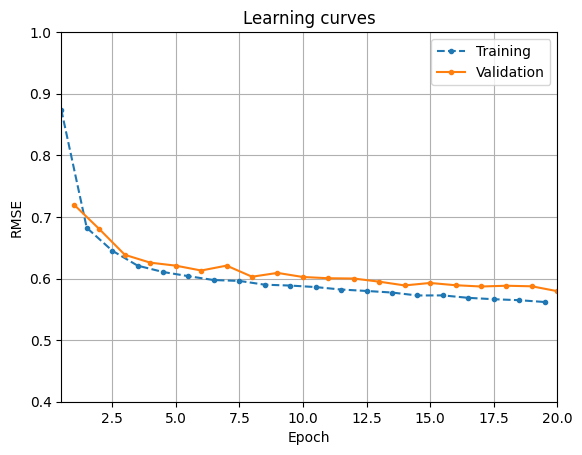

In [ ]:
def train2(model, optimizer, criterion, metric, train_loader, valid_loader, n_epochs):
  history = {"train_loss": [], "train_metrics": [], "valid_metric": []}
  for epoch in range(n_epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
      model.train()
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_pred = model(X_batch)
      loss = criterion(y_batch, y_pred)
      total_loss += loss
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

      metric.update(y_pred, y_batch)
    mean_loss = total_loss / len(train_loader)
    history["train_loss"].append(mean_loss)
    history["train_metrics"].append(metric.compute().item())
    history["valid_metric"].append(evaluate_tm(model, valid_loader, metric).item())

    print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_loss'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metric'][-1]:.4f}")
  return history

torch.manual_seed(42)
learning_rate = 0.01
model = nn.Sequential(
    nn.Linear(n_features, 50), nn.ReLU(),
    nn.Linear(50, 40), nn.ReLU(),
    nn.Linear(40, 30), nn.ReLU(),
    nn.Linear(30, 1)
)

model = model.to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train2(model, optimizer, mse, rmse, train_loader, valid_loader, n_epochs)

plt.plot(np.arange(n_epochs) + 0.5, history["train_metrics"], ".--",
         label="Training")
plt.plot(np.arange(n_epochs) + 1.0, history["valid_metric"], ".-",
         label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.grid()
plt.title("Learning curves")
plt.axis([0.5, 20, 0.4, 1.0])
plt.legend()
plt.show()

Non Sequential Models

In [ ]:
class WideAndDeep(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.deep_stack = nn.Sequential(
        nn.Linear(n_features, 50), nn.ReLU(),
        nn.Linear(50, 40), nn.ReLU(),
    )
    self.output_layer = nn.Linear(40 + n_features, 1)

  def forward(self, X):
    deep_output = self.deep_stack(X)
    wide_and_deep = torch.concat([X, deep_output], dim = 1)
    return self.output_layer(wide_and_deep)

In [ ]:
torch.manual_seed(42)
model = WideAndDeep(n_features).to(device)
learning_rate = 0.002

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)

history = train2(model, optimizer, mse, rmse, train_loader, valid_loader,
                 n_epochs)

Epoch 1/20, train loss: 1.3319, train metric: 1.1542, valid metric: 0.8212
Epoch 2/20, train loss: 0.6115, train metric: 0.7900, valid metric: 0.7855
Epoch 3/20, train loss: 0.5666, train metric: 0.7594, valid metric: 0.7584
Epoch 4/20, train loss: 0.5349, train metric: 0.7369, valid metric: 0.7413
Epoch 5/20, train loss: 0.5118, train metric: 0.7206, valid metric: 0.7271
Epoch 6/20, train loss: 0.4938, train metric: 0.7076, valid metric: 0.7155
Epoch 7/20, train loss: 0.4795, train metric: 0.6969, valid metric: 0.7145
Epoch 8/20, train loss: 0.4677, train metric: 0.6900, valid metric: 0.7010
Epoch 9/20, train loss: 0.4579, train metric: 0.6817, valid metric: 0.6985
Epoch 10/20, train loss: 0.4486, train metric: 0.6756, valid metric: 0.6896
Epoch 11/20, train loss: 0.4425, train metric: 0.6699, valid metric: 0.6927
Epoch 12/20, train loss: 0.4353, train metric: 0.6664, valid metric: 0.6743
Epoch 13/20, train loss: 0.4277, train metric: 0.6581, valid metric: 0.6749
Epoch 14/20, train lo

In [ ]:
class WideAndDeepV2(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.deep_stack = nn.Sequential(
        nn.Linear(n_features, 50), nn.ReLU(),
        nn.Linear(50, 40), nn.ReLU(),
    )
    self.output_layer = nn.Linear(40 + n_features, 1)

  def forward(self, X):
    X_wide = X[:, :5]
    X_deep = X[:, 2:]
    deep_output = self.deep_stack(X_deep)
    wide_and_deep = torch.concat([X_wide, deep_output], dim = 1)
    return self.output_layer(wide_and_deep)

In [ ]:
torch.manual_seed(42)
train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)
valid_data_wd = TensorDataset(X_valid[:, :5], X_valid[:, 2:], y_valid)
valid_loader_wd = DataLoader(valid_data_wd, batch_size=32)
test_data_wd = TensorDataset(X_test[:, :5], X_test[:, 2:], y_test)
test_loader_wd = DataLoader(test_data_wd, batch_size=32)

In [ ]:
class WideAndDeepV3(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.deep_stack = nn.Sequential(
        nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
    )
    self.output_layer = nn.Linear(30 + 5, 1)

  def forward(self, X_wide, X_deep):
    deep_output = self.deep_stack(X_deep)
    wide_and_deep = torch.concat([X_wide, deep_output], dim = 1)
    return self.output_layer(wide_and_deep)

train_data_wd = TensorDataset(X_train[:, :5], X_train[:, 2:], y_train)
train_loader_wd = DataLoader(train_data_wd, batch_size=32, shuffle=True)

def evaluate_multi_in(model, data_loader, metric):
    model.eval()
    metric.reset()  # reset the metric at the beginning
    with torch.no_grad():
        for X_batch_wide, X_batch_deep, y_batch in data_loader:
            X_batch_wide = X_batch_wide.to(device)
            X_batch_deep = X_batch_deep.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch_wide, X_batch_deep)
            metric.update(y_pred, y_batch)  # update it at each iteration
    return metric.compute()  # compute the final result at the end

def train_multi_in(model, optimizer, criterion, metric, train_loader,
                   valid_loader, n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.
        metric.reset()
        for *X_batch_inputs, y_batch in train_loader:
            model.train()
            X_batch_inputs = [X.to(device) for X in X_batch_inputs]
            y_batch = y_batch.to(device)
            y_pred = model(*X_batch_inputs)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        mean_loss = total_loss / len(train_loader)
        history["train_losses"].append(mean_loss)
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_multi_in(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


torch.manual_seed(42)
learning_rate = 0.01
model = WideAndDeepV3(n_features).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0)
mse = nn.MSELoss()
rmse = torchmetrics.MeanSquaredError(squared=False).to(device)
history = train_multi_in(model, optimizer, mse, rmse, train_loader_wd,
                         valid_loader_wd, n_epochs)

Epoch 1/20, train loss: 0.8148, train metric: 0.9028, valid metric: 0.7438
Epoch 2/20, train loss: 0.4907, train metric: 0.7006, valid metric: 0.7199
Epoch 3/20, train loss: 0.4474, train metric: 0.6690, valid metric: 0.6852
Epoch 4/20, train loss: 0.4255, train metric: 0.6524, valid metric: 0.6683
Epoch 5/20, train loss: 0.4142, train metric: 0.6436, valid metric: 0.6568
Epoch 6/20, train loss: 0.4022, train metric: 0.6343, valid metric: 0.6497
Epoch 7/20, train loss: 0.3936, train metric: 0.6273, valid metric: 0.6428
Epoch 8/20, train loss: 0.3854, train metric: 0.6208, valid metric: 0.6316
Epoch 9/20, train loss: 0.3766, train metric: 0.6138, valid metric: 0.6267
Epoch 10/20, train loss: 0.3681, train metric: 0.6067, valid metric: 0.6324
Epoch 11/20, train loss: 0.3661, train metric: 0.6051, valid metric: 0.6148
Epoch 12/20, train loss: 0.3562, train metric: 0.5969, valid metric: 0.6213
Epoch 13/20, train loss: 0.3526, train metric: 0.5938, valid metric: 0.6069
Epoch 14/20, train lo

In [ ]:
class WideAndDeepV3(nn.Module):
  def __init__(self, n_features):
    super().__init__()
    self.deep_stack = nn.Sequential(
        nn.Linear(n_features - 2, 50), nn.ReLU(),
            nn.Linear(50, 40), nn.ReLU(),
            nn.Linear(40, 30), nn.ReLU(),
    )
    self.output_layer = nn.Linear(30 + 5, 1)
    self.aux_output_layer = nn.Linear(30,1)

  def forward(self, X_wide, X_deep):
    deep_output = self.deep_stack(X_deep)
    wide_and_deep = torch.concat([X_wide, deep_output], dim = 1)
    main_outout = self.output_layer(wide_and_deep)
    aux_output = self.aux_output_layer(deep_output)
    return self.output_layer(wide_and_deep)